In [23]:
import casadi as cs
import bifurcations as bf
import dynamics as dn
import numpy as np
from solver import ContinuationSolver
from matplotlib import pyplot as plt
from time import time
from scipy.linalg import null_space

np.set_printoptions(precision=3, suppress=True)

In [24]:
PERIODIC = True
N_STEPS = 100
N_BRANCH = 3
DE_MIN = 1e-6
DE_MAX = 1e-2
U0 = np.array(
    [0.0, 1.01, 0.0, 0.0, 0.0, 0.0, 0.00565685, 0.01525397, 0.00565685, 0.0, 1.01]
)

In [25]:
def estimation(traj_current, dt_current, traj_previous, dt_previous):
    dtraj = traj_current - traj_previous
    traj_next = traj_current + dtraj
    dt_next = dt_current + (dt_current - dt_previous)
    return traj_next, dt_next


def register(traj, dt, branch):
    branch["traj"].append(traj.copy())
    branch["dt"].append(dt.copy())


def init_trajectory(u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = dn.traj_f_list(x0, dt[0], xi)
    traj2 = dn.stance_to_flight(
        dn.traj_s_list(dn.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = dn.traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3)
    return traj,dt,xi

def correction_step(solver,u):
    traj,dt,xi = init_trajectory(u)
    solver.initialize(traj,dt,u[-1])
    traj,dt,xi = solver.solve()
    u=cs.vertcat(0,traj[1:,0],dt,xi,dn.energy_flight(traj[:,0]))
    return u,traj,dt

In [26]:
def process_bifurcation(u, p1):
    J = bf.compute_J(u)
    val, vec = np.linalg.eig(cs.vertcat(J, p1.T))
    idx_val = np.argmin(np.abs(val))
    p2 = vec[:, idx_val].real.reshape((11,1))
    p2 =  p2 - np.dot(p1.T,p2) * p1 
    p2 = p2 / np.linalg.norm(p2)
    val, vec = np.linalg.eig(J @ J.T)
    idx_val = np.argmin(np.abs(val))
    e = vec[:, idx_val].real
    b12 = bf.hessian(u, p1, p2, e)
    b22 = bf.hessian(u, p2, p2, e)
    beta2 = 1
    beta1 = -b22 / (2 * b12)
    p2 = beta1 * p1 + beta2 * p2
    p2 = p2 / np.linalg.norm(p2)
    return p2

In [27]:
traj_init,dt_init,xi_init = init_trajectory(U0)
p_init = null_space(bf.compute_J(U0[:11]))
solver = ContinuationSolver(PERIODIC)

In [28]:
def unconstrained_continuation(solver,u,p,d,N):
    branch = {"traj":[],"dt":[]}
    u,traj,dt = correction_step(solver,u)
    register(traj,dt,branch)
    det_hist = []
    u_hist = []
    p_hist = []

    for step in range(N):
        u = u + np.sign(p[-1])*d*p
        u,traj,dt = correction_step(solver,u)
        u_hist.append(u)
        register(traj,dt,branch)
        J = bf.compute_J(u)
        p = null_space(J)
        p_hist.append(p)
        det_hist.append(np.linalg.det(cs.vertcat(J,p.T)))
        if step>1 and det_hist[-2]*det_hist[-1] < 0:
            coeff = det_hist[-2]/(det_hist[-2] - det_hist[-1])
            u_star = coeff * u_hist[-1] + (1-coeff) * u_hist[-2]
            p1 = coeff * p_hist[-1] + (1-coeff) * p_hist[-2]
            p2 = process_bifurcation(u_star,p1)
            print(p1.T)
            print(p2.T)
            
        

    return branch,det_hist

    

In [29]:
branch,det = unconstrained_continuation(solver,U0,p_init,0.005,50)

[[-0.     0.697  0.    -0.     0.    -0.     0.066 -0.008  0.058  0.146
   0.697]]
[[-0.000452037, -7.57229e-05, -0.193576, 0.687926, -1.74644e-09, 0.69949, -3.4069e-06, 7.09158e-07, 9.41717e-06, 8.66278e-05, -7.57229e-05]]


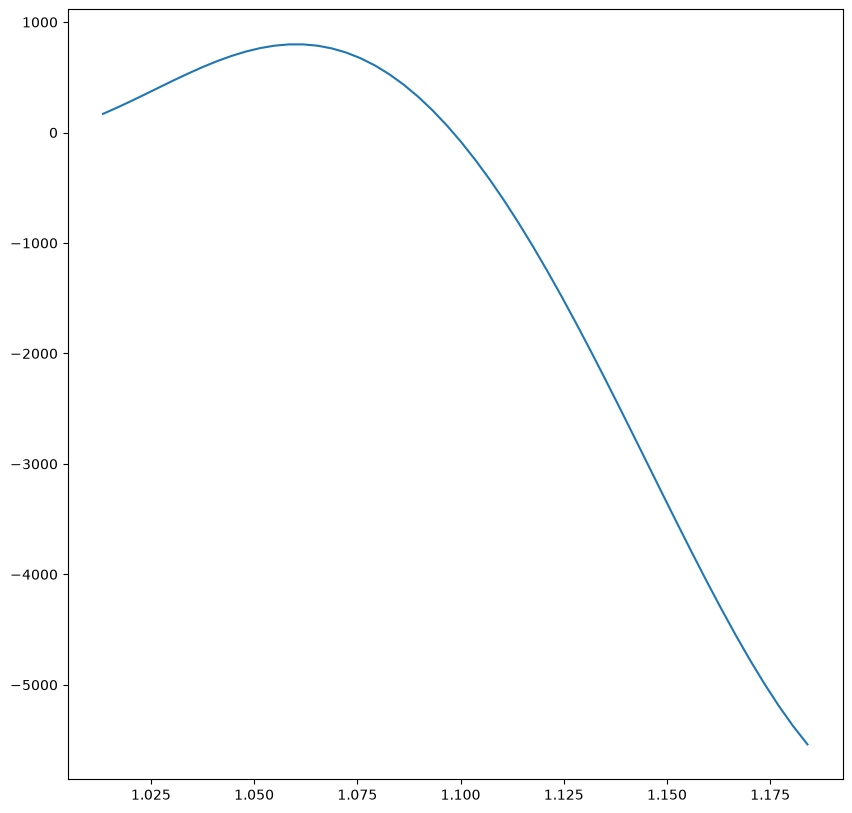

In [30]:
def plot_traj(ax,traj,c):
    ax.plot(traj[1,:],traj[2,:], traj[3,:],linewidth=0.5,color=c)

fig = plt.figure(figsize=(10,10))
# ax = fig.add_subplot(1,1,1,projection="3d")
# for t in branch["traj"]:
#     plot_traj(ax, t,"green")

plt.plot(dn.energy_flight(np.array(branch["traj"])[1:,:,0].T).T,det)
# plt.ylim(-1,1)
plt.show()